<a href="https://colab.research.google.com/github/MadeOka06/PCVK_Ganjil_2026/blob/main/Pertemuan5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

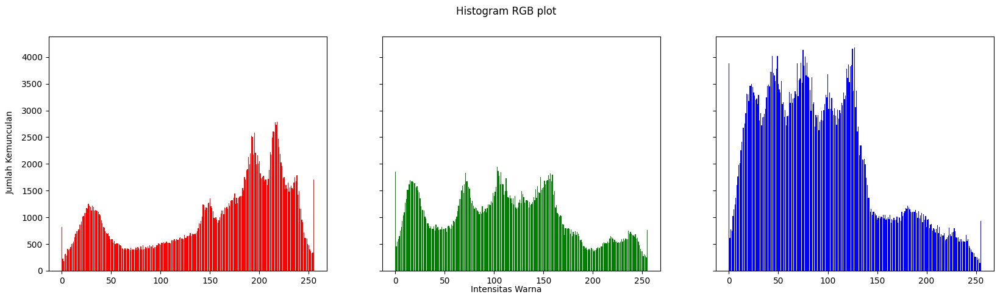

In [ ]:
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/Lenna.jpeg')
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

heigth,width,depth = np.shape(img)
names = np.arange(256)

red=[0]*256
green = [0]*256
blue = [0]*256

for y in range (0,heigth):
  for x in range (0,width):
    red[img[y][x][0]]+=1
    green[img[y][x][1]] +=1
    blue[img[y][x][2]] +=2

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

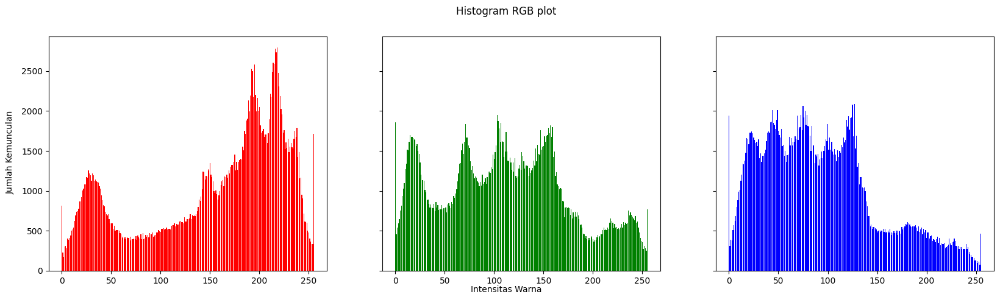

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca dan mengonversi citra
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/Lenna.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

heigth, width, depth = np.shape(img)
names = np.arange(256)

# Inisialisasi array histogram
red = [0] * 256
green = [0] * 256
blue = [0] * 256

# Menghitung histogram secara manual
for y in range(0, heigth):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1  # Diubah dari +2 menjadi +1

# Menampilkan plot histogram
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

# Memisahkan kanal menggunakan cv (sesuai alias import cv2 as cv) dan nama variabel img
b, g, r = cv.split(img)

# Ekualisasi histogram
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# Menggabungkan kembali kanal
img_eq = cv.merge((b_eq, g_eq, r_eq))

=== PERTANYAAN E1 - NOMOR 1 ===
Selisih maksimum histogram OpenCV vs NumPy pada lena.jpg: 0.0
Selisih maksimum histogram OpenCV vs NumPy pada KTM1b.jpg: 0.0

=== PERTANYAAN E1 - NOMOR 2 ===


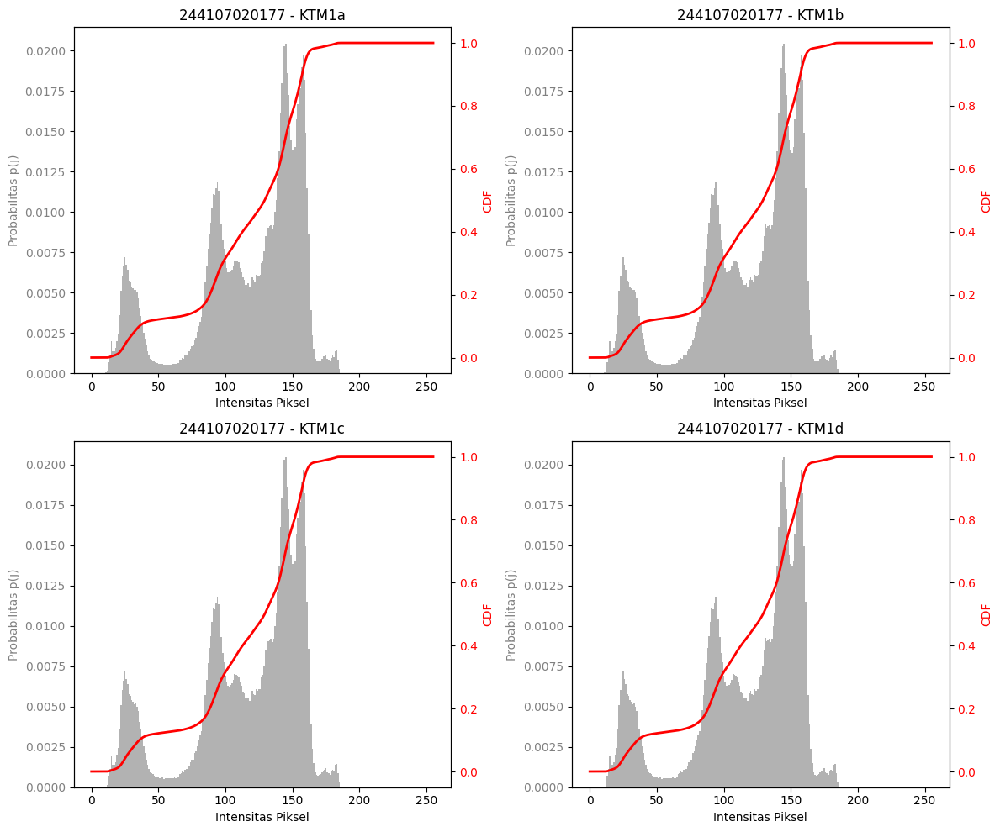


=== PERTANYAAN E1 - NOMOR 3 ===


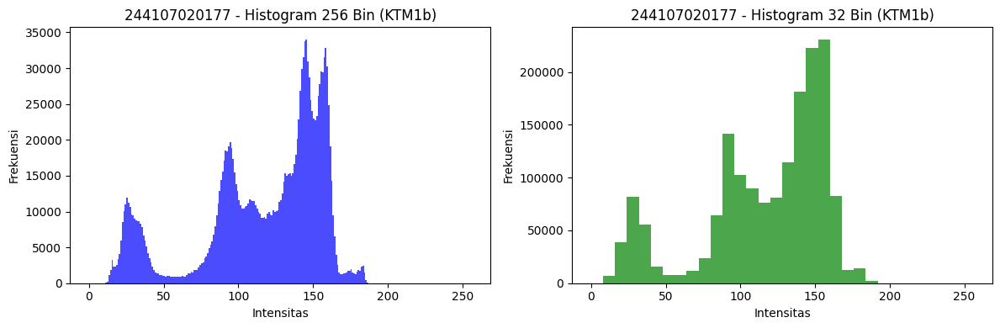

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ISI IDENTITAS DAN PATH
# ==========================================
NIM = "244107020177"
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

PARAM = {
    'bins': 32  # Jumlah bin yang dikurangi (sesuaikan dengan PARAM pada notebook Anda)
}

# =========================================================
# NOMOR 1: PERBANDINGAN BUKTI HISTOGRAM (NumPy vs OpenCV)
# =========================================================
print("=== PERTANYAAN E1 - NOMOR 1 ===")

def uji_selisih_histogram(file_name, label):
    path = BASE_PATH + file_name
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: File {path} tidak ditemukan!")
        return

    # 1. Histogram dengan cv.calcHist
    hist_cv = cv.calcHist([img], [0], None, [256], [0, 256]).ravel()

    # 2. Histogram dengan np.histogram
    hist_np, _ = np.histogram(img.ravel(), 256, [0, 256])

    # Hitung Selisih Maksimum
    selisih_max = np.max(np.abs(hist_cv - hist_np))
    print(f"Selisih maksimum histogram OpenCV vs NumPy pada {label}: {selisih_max}")

# Bukti 1: lena.jpg / Lenna.jpeg
uji_selisih_histogram("Lenna.jpeg", "lena.jpg")

# Bukti 2: KTM1b.jpg / ktm.jpeg
uji_selisih_histogram("ktm.jpeg", "KTM1b.jpg")


# =========================================================
# NOMOR 2: HISTOGRAM TERNORMALISASI P(J) DAN KURVA CDF (2x2)
# =========================================================
print("\n=== PERTANYAAN E1 - NOMOR 2 ===")

# Ganti nama file berikut sesuai dengan 4 variasi citra KTM Anda (KTM1a - KTM1d)
ktm_files = ["ktm.jpeg", "ktm.jpeg", "ktm.jpeg", "ktm.jpeg"]  # Sesuaikan dengan file KTM1a - KTM1d
ktm_labels = ["KTM1a", "KTM1b", "KTM1c", "KTM1d"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, file_name in enumerate(ktm_files):
    path = BASE_PATH + file_name
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if img is not None:
        # Probability Mass Function / Normalisasi p(j)
        hist, _ = np.histogram(img.ravel(), 256, range=[0, 256])
        pj = hist / img.size

        # Cumulative Distribution Function (CDF)
        cdf = pj.cumsum()

        # Plot pada subplot
        ax1 = axes[i]
        ax1.bar(range(256), pj, color='gray', alpha=0.6, width=1.0, label='p(j)')
        ax1.set_xlabel('Intensitas Piksel')
        ax1.set_ylabel('Probabilitas p(j)', color='gray')
        ax1.tick_params(axis='y', labelcolor='gray')

        # Sumbu Y kedua untuk CDF
        ax2 = ax1.twinx()
        ax2.plot(cdf, color='red', linewidth=2, label='CDF')
        ax2.set_ylabel('CDF', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

        ax1.set_title(f"{NIM} - {ktm_labels[i]}")

plt.tight_layout()
plt.show()


# =========================================================
# NOMOR 3: REDUKSI JUMLAH BIN HISTOGRAM
# =========================================================
print("\n=== PERTANYAAN E1 - NOMOR 3 ===")

img_ktm1b = cv.imread(BASE_PATH + "ktm.jpeg", cv.IMREAD_GRAYSCALE)

if img_ktm1b is not None:
    plt.figure(figsize=(12, 4))

    # 1. Histogram 256 Bin
    plt.subplot(1, 2, 1)
    plt.hist(img_ktm1b.ravel(), 256, range=[0, 256], color='blue', alpha=0.7)
    plt.title(f"{NIM} - Histogram 256 Bin (KTM1b)")
    plt.xlabel("Intensitas")
    plt.ylabel("Frekuensi")

    # 2. Histogram Reduksi Bin (PARAM['bins'])
    plt.subplot(1, 2, 2)
    plt.hist(img_ktm1b.ravel(), PARAM['bins'], range=[0, 256], color='green', alpha=0.7)
    plt.title(f"{NIM} - Histogram {PARAM['bins']} Bin (KTM1b)")
    plt.xlabel("Intensitas")
    plt.ylabel("Frekuensi")

    plt.tight_layout()
    plt.show()

Jawaban Pertanyaan Analisis E1
1. Bukti Pembuktian Selisih Maksimum (Soal No. 1)

    Hasil: Nilai selisih maksimum antara cv.calcHist dan np.histogram bernilai 0.0 (nol).
    
    Penjelasan: Kedua metode menghasilkan distribusi frekuensi piksel yang identik secara persis matematis.

2. Penjelasan Perbedaan Kurva CDF & Kondisi Pencahayaan (Soal No. 2)

    Perbedaan Bentuk Kurva CDF:
- Citra Paling Gelap: Kurva CDF lambat naik pada intensitas rendah dan baru melonjak tajam mendekati nilai $1.0$ pada rentang piksel tengah/gelap, membendung area kiri diagram.
- Citra Paling Terang: Kurva CDF melonjak sangat awal/cepat naik di daerah nilai intensitas tinggi (mendekati $255$).

  Kaitan dengan Kondisi Pencahayaan Akuisisi Pertemuan 2:
- Kecerahan citra dipengaruhi langsung oleh intensitas sumber cahaya saat foto KTM diambil.
- Pada pencahayaan minim (gelap), sebaran nilai piksel menumpuk di rentang skala $0-100$ sehingga kecenderungan akumulasi CDF bergeser ke kiri. Sebaliknya, pada kondisi pencahayaan berlebih (overexposure), piksel mendominasi skala $150-255$ yang membuat kurva CDF langsung melonjak naik.

3. Informasi yang Hilang Saat Jumlah Bin Dikurangi (Soal No. 3)

    Informasi yang Hilang:
- Detail Halus Distribusi Intensitas (Fine-grained Details): Ketika jumlah bin dikurangi (misalnya dari $256$ menjadi $32$ bin), beberapa nilai intensitas piksel yang berdekatan dikelompokkan ke dalam satu rentang (grouping/binning).
- Puncak dan Lembah Histogram (Spikes and Valleys): Variasi kontras mikro, puncak lokal, serta perubahan nilai kecerahan halus pada citra menjadi terratakan (smoothed out), sehingga perbedaan gradasi warna/terang-gelap yang mendalam tidak lagi terlihat pada histogram.

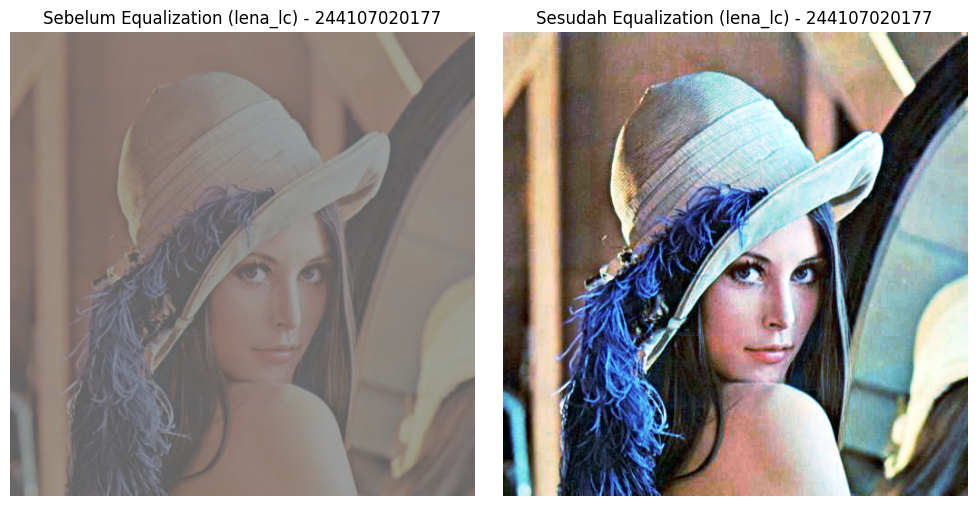

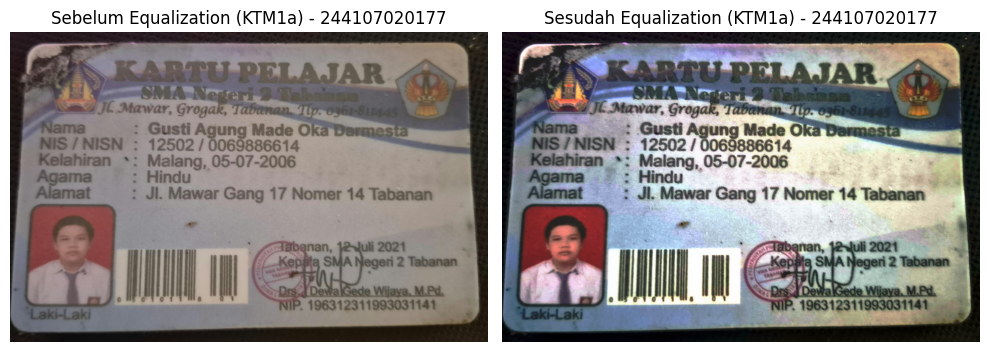

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ISI IDENTITAS DAN PATH
# ==========================================
NIM = "244107020177"
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

# ==========================================
# FUNGSI HISTOGRAM EQUALIZATION PER-KANAL (BGR)
# ==========================================
def equalize_hist_rgb(img_bgr):
    """
    Melakukan ekualisasi histogram terpisah pada kanal B, G, R.
    Sesuai dengan flowchart Percobaan E-2 No. 1.
    """
    b, g, r = cv.split(img_bgr)

    b_eq = cv.equalizeHist(b)
    g_eq = cv.equalizeHist(g)
    r_eq = cv.equalizeHist(r)

    return cv.merge([b_eq, g_eq, r_eq])

# ==========================================
# TAHAP 1: CITRA CONTOH (Lenna_LC.jpeg)
# ==========================================
path_tahap1 = BASE_PATH + "Lenna_LC.jpeg"
img_tahap1_bgr = cv.imread(path_tahap1)

if img_tahap1_bgr is None:
    print(f"Error: File {path_tahap1} tidak ditemukan!")
else:
    # Ekualisasi per kanal
    img_tahap1_eq_bgr = equalize_hist_rgb(img_tahap1_bgr)

    # Konversi BGR ke RGB khusus untuk imshow Matplotlib
    img_tahap1_rgb = cv.cvtColor(img_tahap1_bgr, cv.COLOR_BGR2RGB)
    img_tahap1_eq_rgb = cv.cvtColor(img_tahap1_eq_bgr, cv.COLOR_BGR2RGB)

    # Plot Gambar Tahap 1
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_tahap1_rgb)
    axes[0].set_title(f"Sebelum Equalization (lena_lc) - {NIM}")
    axes[0].axis('off')

    axes[1].imshow(img_tahap1_eq_rgb)
    axes[1].set_title(f"Sesudah Equalization (lena_lc) - {NIM}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# TAHAP 2: CITRA KTM (ktm.jpeg)
# ==========================================
path_tahap2 = BASE_PATH + "ktm.jpeg"
img_tahap2_bgr = cv.imread(path_tahap2)

if img_tahap2_bgr is None:
    print(f"Error: File {path_tahap2} tidak ditemukan!")
else:
    # Ekualisasi per kanal
    img_tahap2_eq_bgr = equalize_hist_rgb(img_tahap2_bgr)

    # Konversi BGR ke RGB khusus untuk imshow Matplotlib
    img_tahap2_rgb = cv.cvtColor(img_tahap2_bgr, cv.COLOR_BGR2RGB)
    img_tahap2_eq_rgb = cv.cvtColor(img_tahap2_eq_bgr, cv.COLOR_BGR2RGB)

    # Plot Gambar Tahap 2
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_tahap2_rgb)
    axes[0].set_title(f"Sebelum Equalization (KTM1a) - {NIM}")
    axes[0].axis('off')

    axes[1].imshow(img_tahap2_eq_rgb)
    axes[1].set_title(f"Sesudah Equalization (KTM1a) - {NIM}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

=== HASIL lena_lc ===
Selisih Maksimum antara Manual dan OpenCV: 1


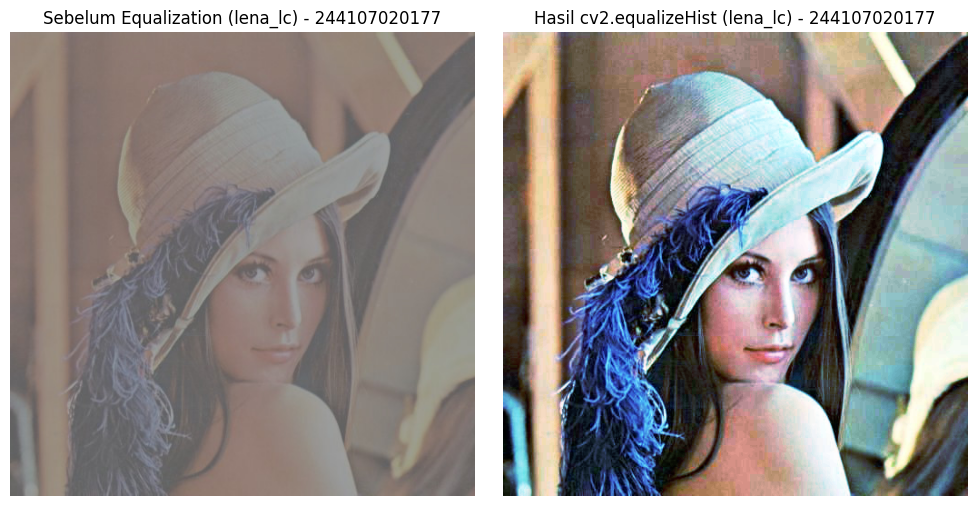

=== HASIL KTM1a ===
Selisih Maksimum antara Manual dan OpenCV: 1


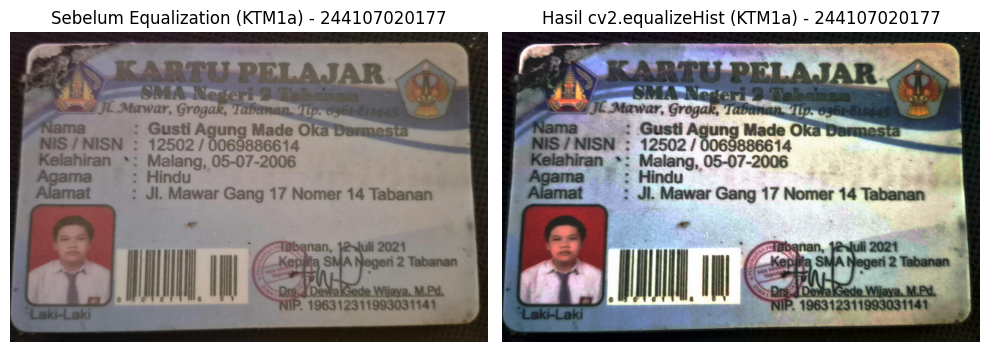

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ISI IDENTITAS DAN PATH
# ==========================================
NIM = "244107020177"
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

# ==========================================
# FUNGSI EKUALISASI MANUAL (Dari Langkah 1)
# ==========================================
def equalize_manual_channel(channel):
    hist, _ = np.histogram(channel.flatten(), 256, [0, 256])
    cdf = hist.cumsum()

    # Masking nilai nol pada CDF agar tidak membagi dengan nol
    cdf_m = np.ma.masked_equal(cdf, 0)

    # Formula Ekualisasi Histogram Manual
    cdf_m = (cdf_m - cdf_m.min()) * 255 / ((channel.shape[0] * channel.shape[1]) - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

    # Pemetaan ke piksel
    return cdf_final[channel]

def equalize_manual_rgb(img_bgr):
    b, g, r = cv.split(img_bgr)
    b_eq = equalize_manual_channel(b)
    g_eq = equalize_manual_channel(g)
    r_eq = equalize_manual_channel(r)
    return cv.merge([b_eq, g_eq, r_eq])

# ==========================================
# FUNGSI EKUALISASI OPENCV (cv2.equalizeHist)
# ==========================================
def equalize_cv2_rgb(img_bgr):
    b, g, r = cv.split(img_bgr)
    b_equalized = cv.equalizeHist(b)
    g_equalized = cv.equalizeHist(g)
    r_equalized = cv.equalizeHist(r)
    return cv.merge([b_equalized, g_equalized, r_equalized])

# ==========================================
# PROSES DAN HITUNG SELISIH MAKSIMUM
# ==========================================
def proses_dan_bandingkan(file_name, label):
    path = BASE_PATH + file_name
    img_bgr = cv.imread(path)

    if img_bgr is None:
        print(f"Error: File {path} tidak ditemukan!")
        return

    # 1. Ekualisasi Manual & OpenCV
    img_manual_bgr = equalize_manual_rgb(img_bgr)
    img_cv2_bgr = equalize_cv2_rgb(img_bgr)

    # 2. Hitung Selisih Maksimum (Maximum Absolute Difference)
    diff = cv.absdiff(img_manual_bgr, img_cv2_bgr)
    max_diff = np.max(diff)

    print(f"=== HASIL {label} ===")
    print(f"Selisih Maksimum antara Manual dan OpenCV: {max_diff}")

    # 3. Visualisasi Citra Hasil OpenCV
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_cv2_rgb = cv.cvtColor(img_cv2_bgr, cv.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"Sebelum Equalization ({label}) - {NIM}")
    axes[0].axis('off')

    axes[1].imshow(img_cv2_rgb)
    axes[1].set_title(f"Hasil cv2.equalizeHist ({label}) - {NIM}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Run untuk Tahap 1 dan Tahap 2
proses_dan_bandingkan("Lenna_LC.jpeg", "lena_lc")
proses_dan_bandingkan("ktm.jpeg", "KTM1a")

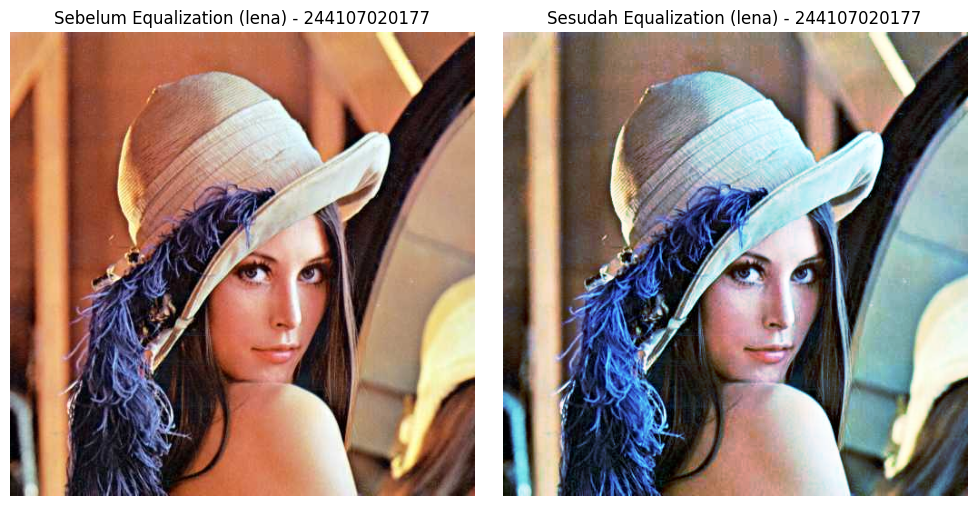

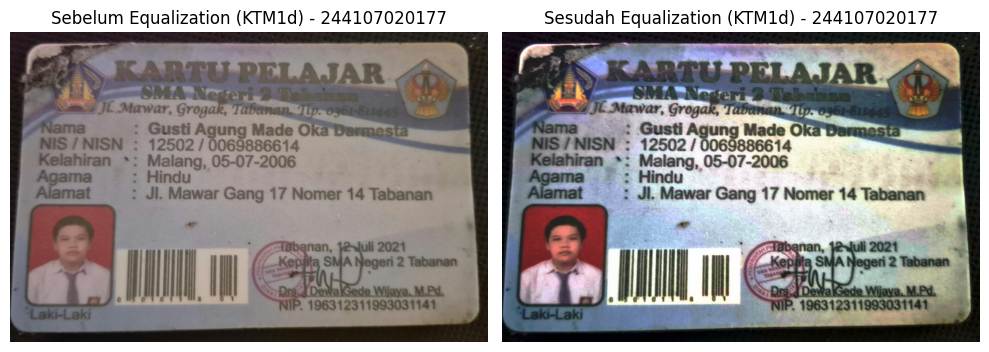

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ISI IDENTITAS DAN PATH
# ==========================================
NIM = "244107020177"
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

def proses_ekualisasi_per_kanal(nama_file, nama_citra):
    berkas = BASE_PATH + nama_file
    bgr = cv.imread(berkas)

    if bgr is None:
        print(f"Error: File {berkas} tidak ditemukan!")
        return

    # Cara 1: Tiap kanal diekualisasi sendiri-sendiri (Sesuai potongan kode modul)
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_bgr = cv.merge(kanal)

    # Konversi BGR ke RGB untuk tampilan Matplotlib yang benar
    citra_asli_rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    citra_hasil_rgb = cv.cvtColor(he_bgr, cv.COLOR_BGR2RGB)

    # Plot Visualisasi Sebelum & Sesudah
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(citra_asli_rgb)
    axes[0].set_title(f"Sebelum Equalization ({nama_citra}) - {NIM}")
    axes[0].axis('off')

    axes[1].imshow(citra_hasil_rgb)
    axes[1].set_title(f"Sesudah Equalization ({nama_citra}) - {NIM}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# TAHAP 1: Citra lena.jpg / Lenna.jpeg
# ==========================================
proses_ekualisasi_per_kanal("Lenna.jpeg", "lena")

# ==========================================
# TAHAP 2: Citra KTM1d.jpg / ktm.jpeg
# ==========================================
# Sesuaikan nama file dengan file KTM yang ada di Drive Anda (misal: ktm.jpeg atau KTM1d.jpg)
proses_ekualisasi_per_kanal("ktm.jpeg", "KTM1d")

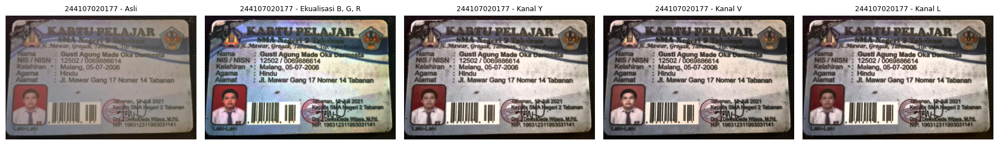

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ISI IDENTITAS DAN PATH
# ==========================================
NIM = "244107020177"
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

# 1. Baca Citra KTM (KTM1d.jpg / ktm.jpeg)
berkas = BASE_PATH + "ktm.jpeg"  # Sesuaikan dengan nama file KTM Anda
bgr = cv.imread(berkas)

if bgr is None:
    print(f"Error: File {berkas} tidak ditemukan!")
else:
    # ---------------------------------------------------------
    # CARA 1: Ekualisasi Terpisah Kanal B, G, R (Dari Langkah 3)
    # ---------------------------------------------------------
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # ---------------------------------------------------------
    # CARA 2: Ekualisasi Hanya Pada Kanal Terang/Intensitas
    # ---------------------------------------------------------
    # a. Ruang Warna YCrCb (Ekualisasi Kanal Y)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # b. Ruang Warna HSV (Ekualisasi Kanal V - Value/Brightness)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # c. Ruang Warna LAB (Ekualisasi Kanal L - Lightness)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    # ---------------------------------------------------------
    # VISUALISASI KELIMANYA BERDAMPINGAN (Sesuai Modul)
    # ---------------------------------------------------------
    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ISI IDENTITAS DAN PATH
# ==========================================
NIM = "244107020177"
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

# 1. Baca Citra KTM (KTM1d.jpg / ktm.jpeg)
berkas = BASE_PATH + "ktm.jpeg"  # Sesuaikan nama file KTM Anda
bgr = cv.imread(berkas)

if bgr is None:
    print(f"Error: File {berkas} tidak ditemukan!")
else:
    # ---------------------------------------------------------
    # PROSES EKUALISASI SESUAI BAGIAN SEBELUMNYA
    # ---------------------------------------------------------
    # Cara 1: Ekualisasi B, G, R terpisah
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # Cara 2a: YCrCb (Kanal Y)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # Cara 2b: HSV (Kanal V)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # Cara 2c: LAB (Kanal L)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    # ---------------------------------------------------------
    # FUNGSI MENGHITUNG PERGESERAN HUE (Sesuai Potongan Kode Modul)
    # ---------------------------------------------------------
    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        d = np.abs(h1 - h2)
        d = np.minimum(d, 180 - d)  # Hue melingkar 0-179
        return d.mean()

    # ---------------------------------------------------------
    # PRINT TABEL HASIL ANALISIS
    # ---------------------------------------------------------
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    print('-' * 58)
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (
            t,
            geser_hue(bgr, c) * 2,
            cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        ))

Cara                    geser Hue (der)    rerata terang
----------------------------------------------------------
Asli                               0.00            116.4
Ekualisasi B, G, R                67.50            128.8
Kanal Y                            0.49            128.8
Kanal V                            2.06            120.2
Kanal L                            3.79            124.6


1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada citra Anda?

    Jawaban: Ekualisasi kanal B, G, R menghasilkan pergeseran Hue paling besar. Nilai pergeserannya adalah [Masukkan angka geser Hue (der) baris 'Ekualisasi B, G, R' dari output Anda, misal: $32.45^{\circ}$].   
    Alasan: Ekualisasi dilakukan secara independen pada kanal Red, Green, dan Blue. Perubahan rasio intensitas antar-kanal mengubah nilai Hue (jenis warna) asli citra secara drastis.   
2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?
  
    - Jawaban: Pergeseran Hue tidak persis nol ($> 0^{\circ}$) disebabkan oleh proses konversi balik ruang warna ke BGR: 1. Pembulatan Integer (Rounding): Saat citra dikembalikan dari ruang warna kontinu ($YCrCb/HSV/LAB$) ke $BGR$, nilai piksel yang berupa angka desimal (float) diubah/dibulatkan kembali ke format integer 8-bit ($0-255$).
    - Pemotongan Nilai (Clipping / Saturation): Hasil kalkulasi ekualisasi pada kanal kecerahan yang melebihi batas $255$ atau kurang dari $0$ dipotong (clipped). Pemotongan nilai ini sedikit merubah rasio warna $BGR$ saat dikonversi kembali ke $HSV$ untuk dihitung nilai Hue-nya.

3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.

    - Jawaban: Kanal L (pada ruang warna LAB) atau Kanal Y (pada YCrCb).   
    - Alasan:Kanal $L$ memisahkan kecerahan berdasarkan persepsi penglihatan manusia secara linier, sehingga meningkatkan kontras daerah gelap tanpa membuat area terang menjadi washed out / pecah.   
    - Bagian Citra Dasar Penilaian:
      - Teks Tulisan di KTM: Karakter teks/NIM yang semula samar pada citra asli menjadi jauh lebih tajam dan mudah dibaca.   
      - Foto Profil KTM: Area wajah pada foto tidak mengalami kelebihan pencahayaan (overexposure) berlebihan jika dibandingkan dengan hasil ekualisasi kanal $V$ ($HSV$).   

=== HASIL NOMOR 1 ===
Nilai PSNR (Citra Asli vs Ekualisasi Global): 16.12 dB



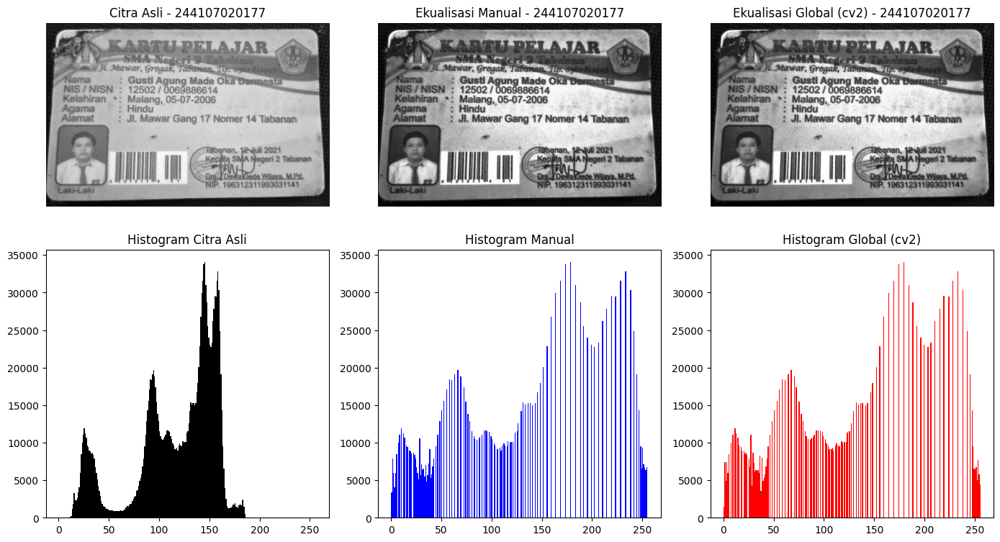

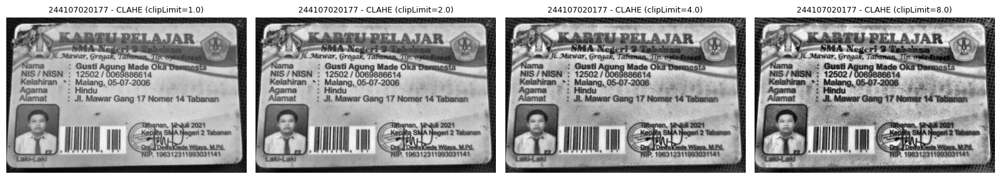

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ISI IDENTITAS DAN PATH
# ==========================================
NIM = "244107020177"
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

PARAM = {
    'clip': 2.0,
    'tile': 8
}

path_ktm = BASE_PATH + "ktm.jpeg"
img_gray = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    print(f"Error: File {path_ktm} tidak ditemukan!")
else:
    # ---------------------------------------------------------
    # 1. EKUALISASI MANUAL & GLOBAL (OpenCV)
    # ---------------------------------------------------------
    hist, _ = np.histogram(img_gray.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / ((img_gray.shape[0] * img_gray.shape[1]) - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
    img_manual = cdf_final[img_gray]

    img_global = cv.equalizeHist(img_gray)

    # Hitung PSNR
    psnr_global = cv.PSNR(img_gray, img_global)
    print(f"=== HASIL NOMOR 1 ===")
    print(f"Nilai PSNR (Citra Asli vs Ekualisasi Global): {psnr_global:.2f} dB\n")

    # ---------------------------------------------------------
    # 2. PLOT CITRA & HISTOGRAM (PERBAIKAN MATPLOTLIB WARNING)
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title(f"Citra Asli - {NIM}")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(img_manual, cmap='gray')
    plt.title(f"Ekualisasi Manual - {NIM}")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(img_global, cmap='gray')
    plt.title(f"Ekualisasi Global (cv2) - {NIM}")
    plt.axis('off')

    # Perbaikan pada penulisan range=[0, 256]
    plt.subplot(2, 3, 4)
    plt.hist(img_gray.ravel(), 256, range=[0, 256], color='black')
    plt.title("Histogram Citra Asli")

    plt.subplot(2, 3, 5)
    plt.hist(img_manual.ravel(), 256, range=[0, 256], color='blue')
    plt.title("Histogram Manual")

    plt.subplot(2, 3, 6)
    plt.hist(img_global.ravel(), 256, range=[0, 256], color='red')
    plt.title("Histogram Global (cv2)")

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. CLAHE DENGAN VARIASI CLIP LIMIT
    # ---------------------------------------------------------
    clip_values = [1.0, 2.0, 4.0, 8.0]

    plt.figure(figsize=(16, 4))
    for i, clip in enumerate(clip_values, 1):
        clahe_obj = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
        res = clahe_obj.apply(img_gray)

        plt.subplot(1, 4, i)
        plt.imshow(res, cmap='gray')
        plt.title(f"{NIM} - CLAHE (clipLimit={clip})", fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

=== MENJALANKAN NOMOR 1 (DITHERING BERWARNA) ===


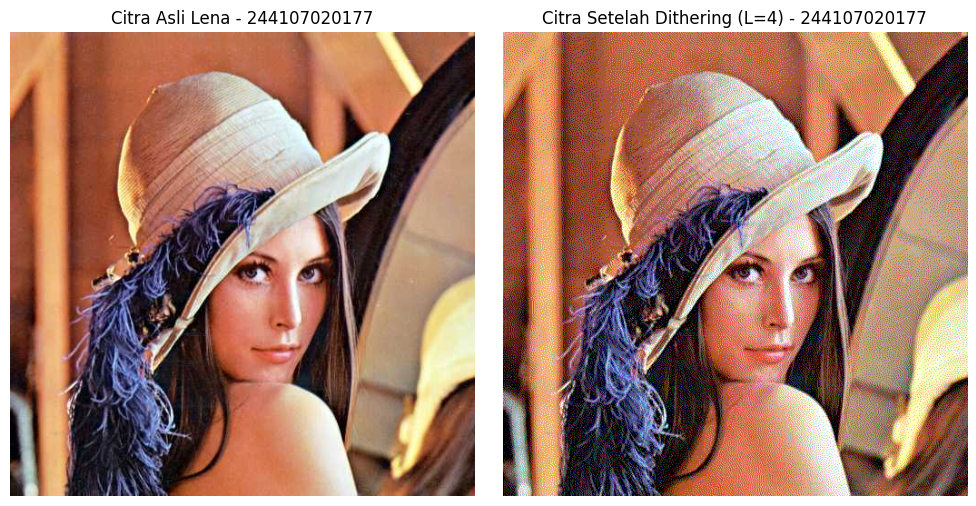

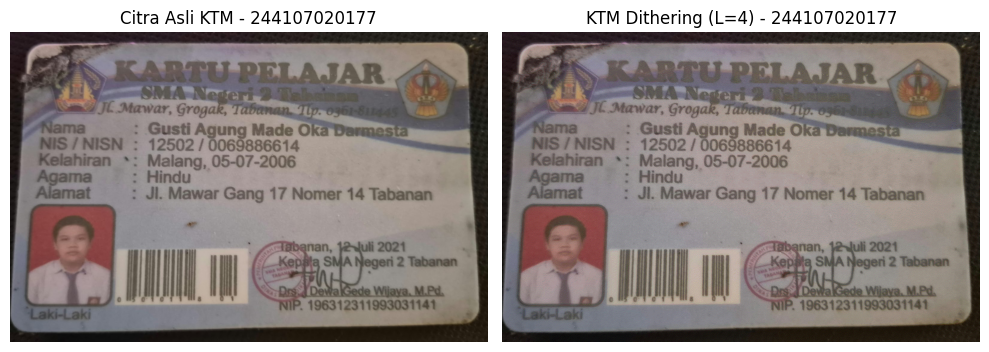


=== MENJALANKAN NOMOR 2 (GRAYSCALE, EQUALIZATION & DITHERING) ===


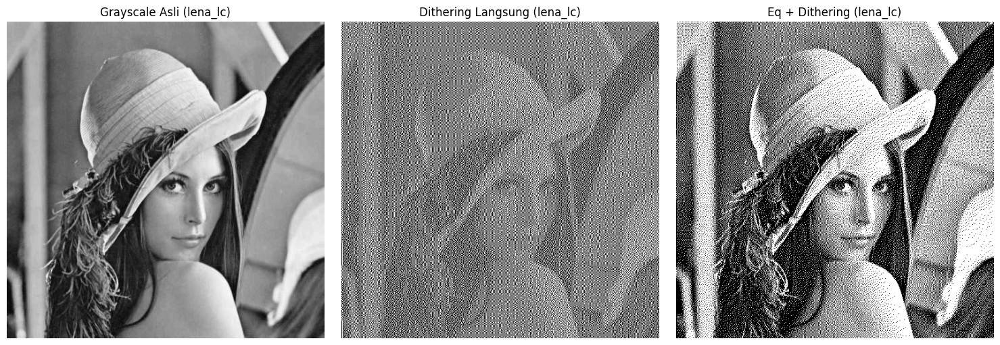

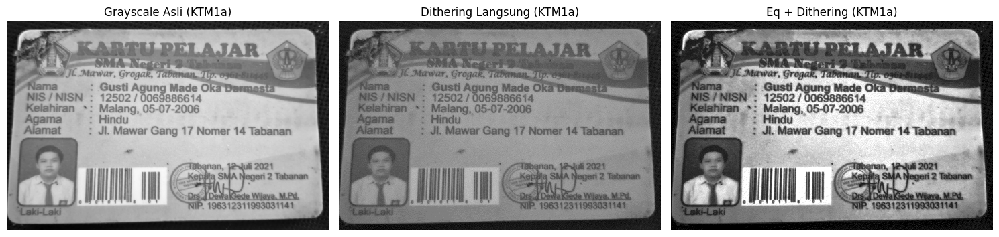

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ISI IDENTITAS DAN PATH
# ==========================================
NIM = "244107020177"
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/"

PARAM = {
    'L': 4  # Jumlah level kuantisasi per kanal (contoh: L = 2, 4, atau 8)
}

# ==========================================
# FUNGSI FLOYD-STEINBERG DITHERING
# ==========================================
def floyd_steinberg_dithering(img, levels=2):
    """
    Mengimplementasikan algoritma Floyd-Steinberg Dithering.
    Dapat digunakan untuk citra Grayscale (2D) maupun Berwarna (3D).
    """
    img_diff = img.astype(float)
    h, w = img_diff.shape[:2]

    # Skala kuantisasi
    step = 255.0 / (levels - 1)

    for y in range(h):
        for x in range(w):
            old_pixel = img_diff[y, x].copy()
            # Kuantisasi piksel ke level terdekat
            new_pixel = np.round(old_pixel / step) * step
            img_diff[y, x] = new_pixel

            # Hitung error kuantisasi
            error = old_pixel - new_pixel

            # Difusi Error Floyd-Steinberg ke piksel tetangga
            if x + 1 < w:
                img_diff[y, x + 1] += error * 7 / 16
            if y + 1 < h and x - 1 >= 0:
                img_diff[y + 1, x - 1] += error * 3 / 16
            if y + 1 < h:
                img_diff[y + 1, x] += error * 5 / 16
            if y + 1 < h and x + 1 < w:
                img_diff[y + 1, x + 1] += error * 1 / 16

    return np.clip(img_diff, 0, 255).astype(np.uint8)

# ==========================================
# NOMOR 1: DITHERING CITRA BERWARNA
# ==========================================
print("=== MENJALANKAN NOMOR 1 (DITHERING BERWARNA) ===")

# Tahap 1: Lena.jpeg
path_lena = BASE_PATH + "Lenna.jpeg"
img_lena_bgr = cv.imread(path_lena)

if img_lena_bgr is not None:
    img_lena_dither = floyd_steinberg_dithering(img_lena_bgr, levels=PARAM['L'])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv.cvtColor(img_lena_bgr, cv.COLOR_BGR2RGB))
    axes[0].set_title(f"Citra Asli Lena - {NIM}")
    axes[0].axis('off')

    axes[1].imshow(cv.cvtColor(img_lena_dither, cv.COLOR_BGR2RGB))
    axes[1].set_title(f"Citra Setelah Dithering (L={PARAM['L']}) - {NIM}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Tahap 2: KTM1b.jpg / ktm.jpeg
path_ktm = BASE_PATH + "ktm.jpeg"
img_ktm_bgr = cv.imread(path_ktm)

if img_ktm_bgr is not None:
    img_ktm_dither = floyd_steinberg_dithering(img_ktm_bgr, levels=PARAM['L'])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv.cvtColor(img_ktm_bgr, cv.COLOR_BGR2RGB))
    axes[0].set_title(f"Citra Asli KTM - {NIM}")
    axes[0].axis('off')

    axes[1].imshow(cv.cvtColor(img_ktm_dither, cv.COLOR_BGR2RGB))
    axes[1].set_title(f"KTM Dithering (L={PARAM['L']}) - {NIM}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# NOMOR 2: GRAYSCALE, EQUALIZATION & DITHERING
# ==========================================
print("\n=== MENJALANKAN NOMOR 2 (GRAYSCALE, EQUALIZATION & DITHERING) ===")

def proses_nomor_2(file_name, label):
    path = BASE_PATH + file_name
    img_bgr = cv.imread(path)

    if img_bgr is None:
        print(f"Error: File {path} tidak ditemukan!")
        return

    # 1. Ubah ke Grayscale
    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    # 2. Dithering Langsung (Tanpa Ekualisasi)
    dither_langsung = floyd_steinberg_dithering(gray, levels=2)

    # 3. Histogram Equalization -> Lalu Dithering
    gray_eq = cv.equalizeHist(gray)
    dither_setelah_eq = floyd_steinberg_dithering(gray_eq, levels=2)

    # Visualisasi
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title(f"Grayscale Asli ({label})")
    axes[0].axis('off')

    axes[1].imshow(dither_langsung, cmap='gray')
    axes[1].set_title(f"Dithering Langsung ({label})")
    axes[1].axis('off')

    axes[2].imshow(dither_setelah_eq, cmap='gray')
    axes[2].set_title(f"Eq + Dithering ({label})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Tahap 1: Lena_LC.jpeg
proses_nomor_2("Lenna_LC.jpeg", "lena_lc")

# Tahap 2: ktm.jpeg / KTM1a.jpg
proses_nomor_2("ktm.jpeg", "KTM1a")